# Transaction Foundation Model on Ray — Part 2: Load & explore the data w/ Ray Data

<div align="left">
  <a target="_blank" href="https://console.anyscale.com/template-preview/fintech_transaction_fm"><img src="https://img.shields.io/badge/🚀 Run_on-Anyscale-9hf"></a>&nbsp;
  <a href="https://github.com/anyscale/templates/tree/main/templates/fintech_transaction_fm" role="button"><img src="https://img.shields.io/static/v1?label=&message=View%20On%20GitHub&color=586069&logo=github&labelColor=2f363d"></a>&nbsp;
</div>

**⏱️ Time to complete**: ~15 min (most of it the one-time dataset download + normalize)


---

Previously in Part 1, we covered the overall plan. Now, we start by downloading the IBM TabFormer benchmark, prep and review the data, and build the training/test splits.

Here we introduce Ray Data.

## Install dependencies and attach to the cluster

The first cell installs the template's dependencies. Ray automatically registers them on every cluster node. Ray also automatically manages your `working_dir` so files are available throughout the ray cluster.

<div style="background-color:#f4f4f5; border-left:4px solid #a1a1aa;
            padding:0.75em 1em; margin:1em 0; color:#3f3f46;
            font-size:0.8em;">

ℹ️ &nbsp; Extra Technical Details: <br>
We pin xgboost to 3.2.0 because the downstream fraud result is sensitive to an early-stopping behavior that changed in 3.3.
</div>


In [1]:
!pip install -q -r requirements.txt

In [2]:
import sys, os, json

DEMO_ROOT = os.path.abspath(os.getcwd())
if DEMO_ROOT not in sys.path:
    sys.path.insert(0, DEMO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import seaborn as sns

import ray
ray.init(ignore_reinit_error=True, runtime_env={"working_dir": DEMO_ROOT},   logging_level=logging.ERROR)

Python version:,3.12.13
Ray version:,2.55.1
Dashboard:,http://session-nridlis6nyy2hi9qv4il5lcj6q.i.anyscaleuserdata.com


## The IBM TabFormer dataset

We are using the [IBM's **TabFormer** benchmark dataset](https://github.com/IBM/TabFormer): 24.4 million credit-card transactions across ~2,000 card-holders and ~6,100 cards, spanning 1991–2020, with a ~0.12% fraud rate. Each transaction is one row with 13 fields — amount, merchant, city, state, merchant category (MCC), timestamp, chip vs online, and so on. These are the raw fields a fraud team would feed to a traditional classifier, and everything the foundation model learns comes from them. TabFormer is the standard public benchmark for transaction models; NVIDIA's blueprint evaluates on it, which is what makes this series' numbers directly comparable to theirs.

We download the CSV once (~2.3 GB, cached under `source/`), convert it to parquet shards since this is what a team would typically store their real data in. A major reason for this is that a single CSV can only be read by one process at a time, while parquet shards are read by every worker in parallel The conversion also stamps each row with its source position in a `__seq__` column to create consistent data splits for training/test.

We define a few `SCALE` configurations for different scenarios. Change this setting and you can run/fast local iterations, or move up to the full production dataset. 
- `mini` keeps 200 card-holders for a quick CPU-only run in minutes
- `small` is the 2-GPU validation run, validates the approach with a small cluster of GPUs
- `full` is the full dataset of all cards. 

The presets live in `configs/`, and outputs are written under per-scale paths (`.../nvsplit/<scale>/`) so scales don't overwrite each other.

In [3]:
from src.paths import artifact_paths, get_demo_base_dir
from src.scale_config import load_scale
from src.tabformer import ensure_download, add_analysis_columns
from src.nvsplit import ensure_parquet_shards, normalize_date_column, ordered_parquet_files
from ray.data.expressions import col

# Configure the 'scale' of the data we work with
SCALE = "mini"             # mini = 200 card-holders on CPU, minutes; full = every card
cfg = load_scale(SCALE)    # configs/<SCALE>.yaml — data knobs here; model/training in later parts
paths = artifact_paths(get_demo_base_dir(), SCALE)   # outputs namespaced per scale
max_users = cfg["data"]["max_users"]                 # None = every card-holder (full)

# Download the CSV once
csv_path = ensure_download(paths["source"])               # one-time ~2.3GB download
ensure_parquet_shards(csv_path, paths["source_parquet"])  # one-time CSV -> seq-tagged shards,
                                                          # runs as a Ray task on a worker

# Read the shards as one Ray dataset — one read task per shard, scheduled onto
# however many CPU workers the cluster has (the autoscaler adds more if tasks queue).
source = ray.data.read_parquet(ordered_parquet_files(paths["source_parquet"]))

# map_batches runs a plain pandas function on each batch, in parallel on the workers.
source = source.map_batches(normalize_date_column, batch_format="pandas")

# mini and small only: keep the first N card-holders. filter takes a column
# expression — the declared predicate runs on the workers.
if max_users is not None:
    source = source.filter(expr=col("User") < max_users)

# Format human-readable columns, like Amount ("$110.23"), as plain typed values.
txns = source.map_batches(add_analysis_columns, batch_format="pandas")

# This line is what makes Ray run: to_pandas() consumes the dataset, executing the
# steps above. limit(5) means only the first few rows are read and returned.
txns.limit(5).to_pandas()[["User", "Card", "timestamp", "amount", "Merchant Name",
                           "MCC", "Use Chip", "Merchant State", "is_fraud"]]

,User,Card,timestamp,amount,Merchant Name,MCC,Use Chip,Merchant State,is_fraud
0,75,1,2005-06-13 17:24:00,18.10,3639123430068731390,5814,Swipe Transaction,AL,0
1,75,1,2005-06-14 13:00:00,21.75,1799189980464955940,5499,Swipe Transaction,AL,0
2,75,1,2005-06-14 13:20:00,83.00,1799189980464955940,5499,Swipe Transaction,AL,0
3,75,1,2005-06-14 13:27:00,-83.00,1799189980464955940,5499,Swipe Transaction,AL,0
4,75,1,2005-06-14 17:06:00,34.86,-1396821880537214279,5816,Swipe Transaction,AL,0


## One card is one sequence

The foundation model reads each card's history as one time-ordered sequence. In Part 4 it learns to predict every transaction from the ones before it, the way a language model predicts the next word in a sentence. This matters for fraud because some patterns only show up across consecutive transactions. The card below is a real example: routine Texas purchases, then a burst of department-store charges from Mexico, escalating from $45 to $514. 

In [4]:
# Card 66000 is an example of a fruadulent transaction. 
# Remember is_fraud is labeled data - its known to be true, its not a prediction.
#
# Using Ray: this is a simple filter query that runs across the cluster to find all 
# transactions from our chosen card
CARD = 66000
seq = txns.filter(expr=col("card_id") == CARD) \
          .to_pandas().sort_values("timestamp").reset_index(drop=True)

# Show the sequence around the first fraud: routine purchases, then the burst.
first = int(seq["is_fraud"].idxmax())
print(f"card {CARD}: {len(seq):,} transactions, {int(seq['is_fraud'].sum())} fraudulent")
seq.iloc[first - 3:first + 7][["timestamp", "amount", "Merchant Name", "MCC",
                               "Merchant State", "is_fraud"]]

card 66000: 29,361 transactions, 48 fraudulent


,timestamp,amount,Merchant Name,MCC,Merchant State,is_fraud
1421,2000-11-15 07:19:00,37.53,-1688244360627004732,4784,None,0
1422,2000-11-15 10:37:00,5.04,7069584154815291371,5812,TX,0
1423,2000-11-16 07:09:00,33.84,-1688244360627004732,4784,None,0
1424,2000-11-16 13:15:00,45.13,-245178307025547046,5311,Mexico,1
1425,2000-11-16 13:52:00,43.41,-6161792371494728879,3389,Mexico,1
1426,2000-11-16 14:20:00,81.98,-5581123930363301609,5311,Mexico,1
1427,2000-11-16 15:05:00,42.42,-245178307025547046,5311,TX,0
1428,2000-11-16 15:49:00,122.75,-5581123930363301609,5311,Mexico,1
1429,2000-11-16 17:54:00,514.02,3189517333335617109,5311,Mexico,1
1430,2000-11-17 10:30:00,2.15,-2527840007093428398,5411,TX,0


## Split the data: train, validation, test

A fraud model is always used the same way: train on past transactions, score new ones as they arrive. The evaluation needs to match that, so we split by time. The model trains on the earliest 80% of transactions, validates on the next 10%, and is tested on the most recent 10%. A random split would let the model train on transactions that come after the ones it's tested on — its score would be inflated by information it could never have in production.

This is also where the evaluation sets come from: a seeded 100K-row sample of val and of test that keeps the natural ~0.1% fraud rate. Every model in this series is scored on these same rows, so evaluation stays cheap and every number stays comparable. We split the data exactly the way NVIDIA does — same cutoff rule, same sampling code, same seeds — so our results can be compared directly to theirs.

Building the split takes three steps: find the two cutoff dates, write the three splits, and draw the evaluation samples. Each step uses Ray differently, so we'll take them one at a time.

### Find the cutoff dates

We need two dates: the day by which 80% of all transactions have happened — train ends there — and the day the count crosses 90%, where val ends and test begins. To find them we need each day's transaction count, plus a running total over the days in order.

We do the counting distributed: `groupby("date").count()` runs across the CPU workers and sends back only the result — about 7,000 daily counts instead of 24 million rows. The running total we do locally: 7,000 rows is a pandas one-liner on the driver (`cutoff_dates`). That division is the pattern for aggregating data that doesn't fit one machine: keep the data distributed, bring back only the small result, finish with ordinary local code.

In [5]:
from src.nvsplit import cutoff_dates

# Count transactions per day. The counting runs on the workers; ~7K daily
# totals come back to the driver.
daily = source.groupby("date").count().to_pandas()

# NVIDIA's cutoff rule: the first dates where the cumulative count crosses
# 80% (train|val) and 90% (val|test) of all transactions.
train_cutoff, test_cutoff = cutoff_dates(daily)
print(f"train < {train_cutoff:%Y-%m-%d} <= val < {test_cutoff:%Y-%m-%d} <= test")

(HashShuffleAggregator pid=69426, ip=10.0.108.81) Converting a 'D' precision datetime NumPy array to 's' precision Arrow timestamp. This conversion occurs because Arrow supports fewer precisions than Arrow and might result in a loss of precision or unrepresentable values.


train < 2017-04-17 <= val < 2018-09-29 <= test


### Write the training/validation/test splits

We have the date ranges, so now we filter and write each of the three split datasets. Each split is one pass across the CPU workers which writes to shared storage as parquet.

Afterwards, we draw the evaluation samples, and here we deliberately stop distributing. The seeded 100K draw is small and order-sensitive, so we run NVIDIA's sampling code unchanged, one Ray task per evaluation set — this time submitting the tasks ourselves with `.remote()` and collecting the results with `ray.get()`. This is a consistent dataset we use for evaluation.

One detail is needed to make the distributed code reproducible. A distributed engine doesn't promise which rows land in which output file when it writes in parallel. So every row carries its original position in a `__seq__` column that was set up earlier during preprocessing the CSV. All order-sensitive steps sort by this key. The result is byte-identical to NVIDIA's single-GPU implementation: the same 19.5M train rows in the same order.

In [6]:
from src.nvsplit import part_filters, fresh_part_dirs, stratified_eval, fraud_count, write_split_meta
import shutil

if not os.path.exists(os.path.join(paths["nvsplit"], "split_meta.json")):
    # One date-range filter per split.
    filters = part_filters(train_cutoff, test_cutoff)

    dirs = fresh_part_dirs(paths["nvsplit"])   # temp output dir per split
    for split, keep_rows in filters.items():
        # Run the filter over `source` (our lazy dataset) on the CPU workers and
        # write the surviving rows to shared storage.
        source.map_batches(keep_rows, batch_format="pandas").write_parquet(dirs[split])

    # stratified_eval picks 100K random rows from a split to evaluate on, keeping
    # the fraud rate the same as the whole split (NVIDIA's code). fraud_count counts
    # the fraudulent transactions in train. Both are Ray tasks: .remote() starts
    # each one on a worker, ray.get() waits for all three results.
    SEED = 42                                    # fixed seed -> same rows every run
    n_eval = cfg["data"]["eval_samples"]         # eval sample size (100K)
    val_out = os.path.join(paths["nvsplit"], "val_eval.parquet")
    test_out = os.path.join(paths["nvsplit"], "test_eval.parquet")
    val_stats, test_stats, train_stats = ray.get([
        stratified_eval.remote(dirs["val"], val_out, n_eval, SEED),   # rows in -> parquet out
        stratified_eval.remote(dirs["test"], test_out, n_eval, SEED),
        fraud_count.remote(dirs["train"]),
    ])

    # Clean up and write out the split metadata to split_meta.json.
    shutil.rmtree(dirs["val"]); shutil.rmtree(dirs["test"])
    meta = write_split_meta(paths["nvsplit"], train_cutoff, test_cutoff,
                            n_eval, max_users, SEED,
                            train_stats, val_stats, test_stats)
else:
    meta = json.load(open(os.path.join(paths["nvsplit"], "split_meta.json")))
    print("split already built at", paths["nvsplit"])
print(json.dumps(meta, indent=2))

(autoscaler +58s) [autoscaler] [32cpu-128gb] Attempting to add 3 nodes to the cluster (increasing from 2 to 5).


{
  "source": "tabformer_csv",
  "protocol": "NVIDIA NB01: 80/10/10 temporal by cumulative daily count + 100K stratified eval",
  "impl": "ray-data-cpu",
  "train_cutoff": "2017-04-17",
  "test_cutoff": "2018-09-29",
  "eval_samples": 100000,
  "max_users": 200,
  "seed": 42,
  "train": {
    "rows": 1934284,
    "fraud": 2274,
    "fraud_rate": 0.0011756288114878684
  },
  "val_eval": {
    "rows": 100000,
    "fraud": 86,
    "fraud_rate": 0.00086
  },
  "test_eval": {
    "rows": 100000,
    "fraud": 108,
    "fraud_rate": 0.00108
  }
}


### Check what we built

The split is on shared storage now; every later notebook reads it from there. As a check, read the train part back and summarize it — the same pattern as the cutoff step: the counting runs on the workers, and small tables return.

In [7]:
from src.nvsplit import train_parquet_files

train = ray.data.read_parquet(train_parquet_files(paths["nvsplit"])) \
                .map_batches(add_analysis_columns, batch_format="pandas")
split_meta = json.load(open(os.path.join(paths["nvsplit"], "split_meta.json")))

# Distributed aggregations — each returns a SMALL table to the driver (thousands of
# cards / hundreds of months), never the transactions themselves.
per_card = train.groupby("card_id").count().to_pandas().rename(columns={"count()": "txns"})
monthly = train.groupby("month").count().to_pandas() \
               .rename(columns={"count()": "txns"}).sort_values("month")
fraud_txns = int(train.sum("is_fraud"))
n_txns = int(per_card["txns"].sum())
fraud_rate = fraud_txns / n_txns

print(f"train transactions ...... {n_txns:,}")
print(f"cards ................... {len(per_card):,}")
print(f"txns per card ........... median {int(per_card['txns'].median()):,}  "
      f"(min {per_card['txns'].min():,}, max {per_card['txns'].max():,})")
print(f"train months ............ {monthly['month'].iloc[0]} -> {monthly['month'].iloc[-1]}")
print(f"train fraud rate ........ {fraud_rate*100:.3f}%  ({fraud_txns:,} fraudulent txns)")
print()
print("temporal split cutoffs (split_meta.json — the same split every stage uses):")
print(f"  train  <  {split_meta['train_cutoff']}")
print(f"  test   >= {split_meta['test_cutoff']}")
print(f"  eval subsets: val {split_meta['val_eval']['rows']:,} rows, "
      f"test {split_meta['test_eval']['rows']:,} rows "
      f"(stratified, ~{split_meta['test_eval']['fraud_rate']*100:.2f}% fraud)")

(autoscaler +1m27s) [autoscaler] [32cpu-128gb|m5.8xlarge] [us-west-2b] [on-demand] Launched 3 instances.


train transactions ...... 1,934,284
cards ................... 451
txns per card ........... median 2,852  (min 1, max 28,903)
train months ............ 1995-06 -> 2017-04
train fraud rate ........ 0.118%  (2,274 fraudulent txns)

temporal split cutoffs (split_meta.json — the same split every stage uses):
  train  <  2017-04-17
  test   >= 2018-09-29
  eval subsets: val 100,000 rows, test 100,000 rows (stratified, ~0.11% fraud)


## Inspecting the data distributions

Four views of the training data, each feeding a design decision in the notebooks ahead. The per-card and monthly panels reuse the aggregations above; the amount histogram samples ~1M rows on the workers; the inter-transaction gaps need each card's rows together, so `groupby("card_id").map_groups` computes them one card at a time across the cluster.

(autoscaler +2m8s) [autoscaler] Cluster upscaled to {160 CPU, 0 GPU}.


(autoscaler +2m12s) [autoscaler] Cluster upscaled to {192 CPU, 0 GPU}.


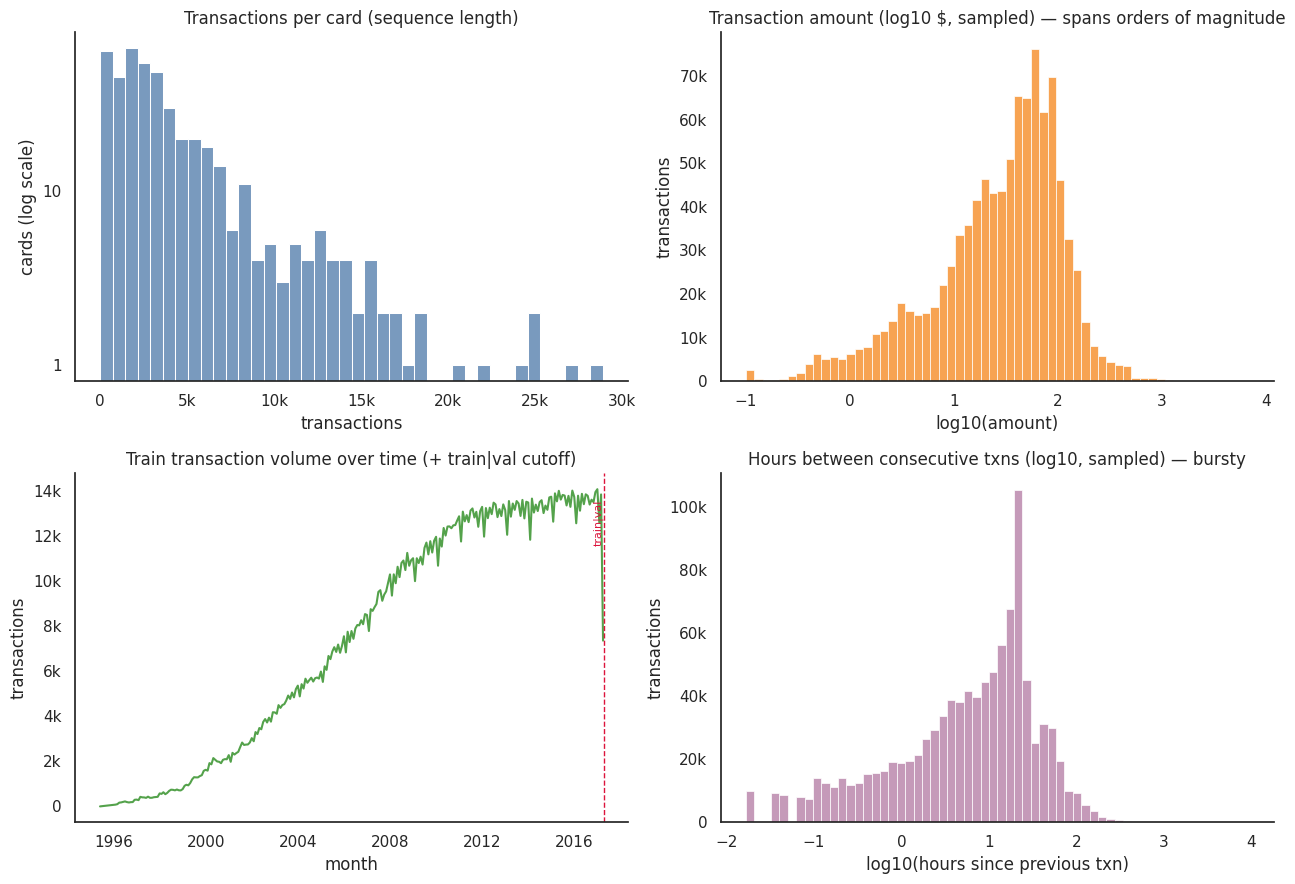

In [8]:
sns.set_theme(style="white", context="notebook")
from matplotlib.ticker import FuncFormatter
from src.tabformer import card_gap_hours

# Human-readable axis numbers: 600000 -> "600k", 2_000_000 -> "2M".
def _human(x, _):
    x = float(x)
    if abs(x) >= 1_000_000: return f"{x / 1e6:g}M"
    if abs(x) >= 1_000:     return f"{x / 1e3:g}k"
    return f"{x:g}"
human = FuncFormatter(_human)

# Per-transaction histograms only need a sample — draw ~1M rows on the workers. The
# inter-transaction gaps need each card's rows together: groupby("card_id").map_groups
# runs one card at a time across the cluster.
frac = min(1.0, 1_000_000 / max(n_txns, 1))
amt_sample = train.random_sample(frac).to_pandas()["amount"]
gap_sample = (train.groupby("card_id").map_groups(card_gap_hours, batch_format="pandas")
              .random_sample(frac).to_pandas()["gap_hours"])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) transactions per card -> motivates the sequence window length (seq_len).
ax = axes[0, 0]
sns.histplot(per_card["txns"], bins=40, color="#4C78A8", ax=ax)
ax.set_yscale("log")
ax.set_title("Transactions per card (sequence length)")
ax.set_xlabel("transactions"); ax.set_ylabel("cards (log scale)")
ax.xaxis.set_major_formatter(human); ax.yaxis.set_major_formatter(human)

# (2) amount spans orders of magnitude -> the tokenizer's fixed dollar-threshold buckets.
ax = axes[0, 1]
log_amt = np.log10(np.clip(np.abs(amt_sample.to_numpy()), 0.1, None))
sns.histplot(log_amt, bins=60, color="#F58518", ax=ax)
ax.set_title("Transaction amount (log10 $, sampled) — spans orders of magnitude")
ax.set_xlabel("log10(amount)"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

# (3) train volume over time, with the train|val temporal cutoff (test = later, not shown).
ax = axes[1, 0]
sns.lineplot(x=pd.PeriodIndex(monthly["month"], freq="M").to_timestamp(),
             y=monthly["txns"].to_numpy(), color="#54A24B", ax=ax)
cut = pd.Timestamp(split_meta["train_cutoff"])
ax.axvline(cut, color="crimson", ls="--", lw=1)
ax.text(cut, ax.get_ylim()[1] * 0.92, "train|val", rotation=90,
        va="top", ha="right", color="crimson", fontsize=8)
ax.set_title("Train transaction volume over time (+ train|val cutoff)")
ax.set_xlabel("month"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

# (4) inter-transaction gaps are bursty -> why the tokenizer carries explicit time fields.
ax = axes[1, 1]
sns.histplot(np.log10(gap_sample.to_numpy()), bins=60, color="#B279A2", ax=ax)
ax.set_title("Hours between consecutive txns (log10, sampled) — bursty")
ax.set_xlabel("log10(hours since previous txn)"); ax.set_ylabel("transactions")
ax.yaxis.set_major_formatter(human)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Reading the four panels:

1. **Transactions per card.** Activity spans a handful to nearly 50,000 transactions, with a median around 2,500. The pretrain window (Part 3) has to serve both ends: long enough to carry real context for active cards, short enough that the many short-history cards aren't mostly padding.
2. **Transaction amount.** Amounts cluster in the tens of dollars (median ~\$33) with a tail out to thousands. The step from \$10 to \$100 matters like the step from \$100 to \$1,000, so the tokenizer buckets amounts at fixed dollar thresholds (\$0/10/50/100/500/1K/5K) instead of feeding a raw scalar.
3. **Volume over time.** Volume grows through the 2000s and then levels off, so the count-based 80/10/10 cutoffs land in the most recent years — the model trains on the past and is tested on what comes after.
4. **Time between transactions.** The median gap is ~9 hours and a fifth of transactions arrive within an hour of the previous one, with a tail out to days. Ordinal position alone loses that, so each transaction carries explicit hour, day-of-week, and month tokens. (NVIDIA also ships an optional time-delta tokenizer that encodes the gap itself; the blueprint leaves it off, and so do we.)

## Scaling factors

24 million rows is 2.3 GB of CSV — a single machine with pandas can process this dataset, and for a one-off analysis it should. The reason to build the split as a distributed pipeline is what changes when the data grows: at production scale, transactions run to billions of rows, and a pipeline written against one machine's memory gets rewritten.

Each piece of this notebook scales along a different axis. The filter passes are linear in rows and split across parquet shards, so 10× the data means 10× the shard reads — absorbed by adding CPU workers, a cluster-config change rather than a code change. The aggregations are bounded by their output, not their input: daily counts return ~7,000 rows whether the source is 24 million or 24 billion. The per-card work (the gap histogram here, the tokenizer in Part 3) parallelizes across cards, and card count is exactly what grows when an institution's book grows. Nothing in the code names a node count or a data size; the worker pool is the only thing that changes.

## How we measure fraud performance

Only about 1 transaction in 800 is fraudulent, so accuracy is meaningless — a model that flags nothing scores 99.9%. Part 1 explains the two metrics we use instead, Average Precision (AP) and AUC-ROC; the number every later notebook optimizes is AP on the 100K-row test eval set built above.

The stratified eval sets preserve the natural fraud rate, which means the full-scale test set holds only ~112 fraudulent transactions. With that few positives, any single AP score is noisy, which is why Part 6 reports distributions over repeated fits rather than one number.

In [9]:
print(f"normal transactions : {(1 - fraud_rate) * 100:.3f}%")
print(f"fraud transactions  : {fraud_rate * 100:.3f}%")
print(f"imbalance ratio     : ~1 fraud per {int(round(1 / fraud_rate)):,} transactions")

normal transactions : 99.882%
fraud transactions  : 0.118%
imbalance ratio     : ~1 fraud per 851 transactions


## Takeaways

This notebook produced the artifact every later stage reads: the temporal 80/10/10 split plus seeded 100K eval sets, on shared storage, verified identical to NVIDIA's single-GPU reference. The Ray Data pattern it used — parquet shards read in parallel, filters and per-card work on autoscaled CPU workers, small aggregates back to the driver, explicit `__seq__` ordering — is the same one Parts 3 and 5 build on. And the data set the design agenda for Part 3: amounts need bucketing, time needs explicit tokens, and card histories need windowing.

---

## Next

**Part 3 — Tokenize**: turn each card's transaction rows into token sequences with NVIDIA's `FinancialTabularTokenizer` (merchant hashing + category hierarchy + temporal encoding, vocab 6251) and build the pretraining corpus.